In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_csv('C:/Users/wolf2/anaconda_projects/churn.csv') 
df = df.drop('RowNumber', axis=1)


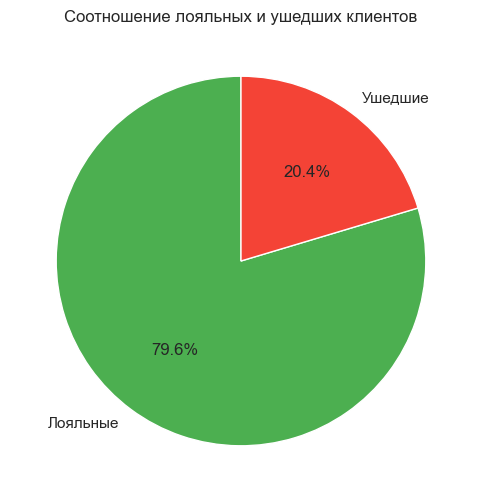

In [5]:
data = df['Exited'].value_counts()
plt.pie(data, labels=['Лояльные', 'Ушедшие'], autopct='%.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
plt.title('Соотношение лояльных и ушедших клиентов')
plt.show()

### Резюме по графику лояльных и ушедших клиентов:
1. Наблюдается большой отток клиентов.
2. Практически каждый пятый клиент, решил уйти в другой банк.
3. Требуется провести анализ причин оттока клиентов для выявления причин и их устранения.

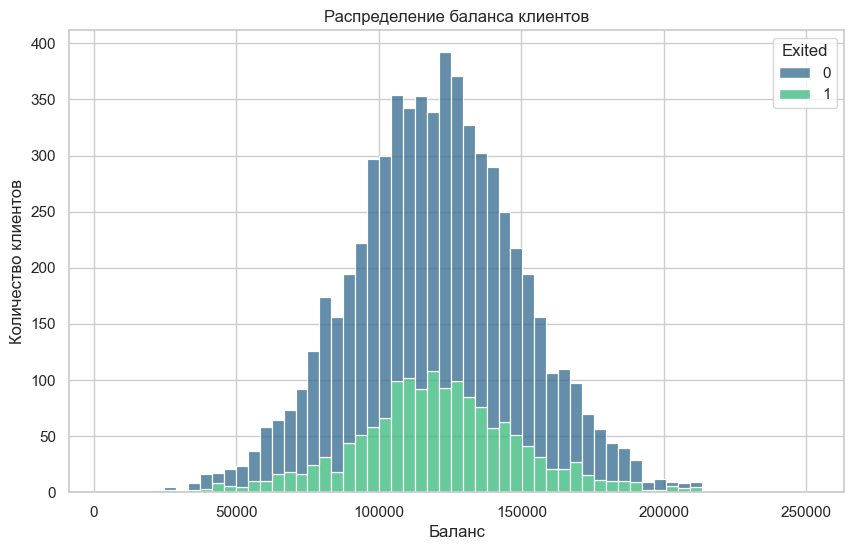

In [31]:
filtered_df = df[df['Balance'] > 2500]
sns.histplot(data= filtered_df, x='Balance', hue='Exited', multiple='stack', palette='viridis')
plt.title('Распределение баланса клиентов')
plt.xlabel('Баланс')
plt.ylabel('Количество клиентов')
plt.show()

### Резюме по графику Распределения баланса клиентов:
1. Наибольший отток клиентов был в группе с балансом от 100к до 150к
2. Структура оттока в целом повторяет структуру распределения лояльных клиентов, можно предположить, что размер баланса не является ключевы фактором оттока клиентов. И требуется проанализировать другие причины.

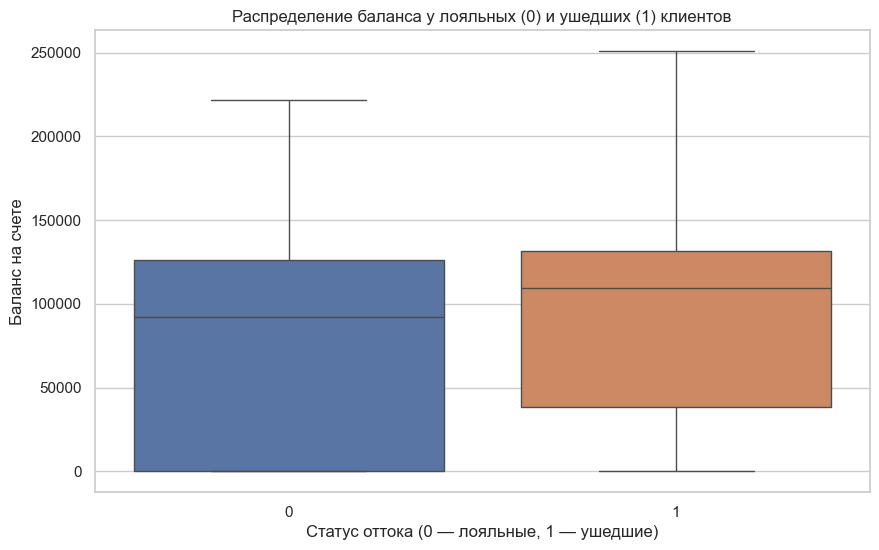

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited', legend=False)
plt.title('Распределение баланса у лояльных (0) и ушедших (1) клиентов')
plt.xlabel('Статус оттока (0 — лояльные, 1 — ушедшие)')
plt.ylabel('Баланс на счете')
plt.show()

### Резюме по графику Распределения баланса у лояльных и ушедших клиентов:
1. Медианный баланс у ушедших клиентов, заметно выше, чем у лояльних. Банк теряет клиентов, которые хранят на счетах более крупные суммы.
2. Это может быть связано с тем, что банк ввел повысил комисиию по операциям, либо наименьшая процентная ставка по вкладам в сравнении с конкурентами. Возможно банк ввел "заградительные" условия - повышенная ставка за обсулживание счетов с большим остатком.

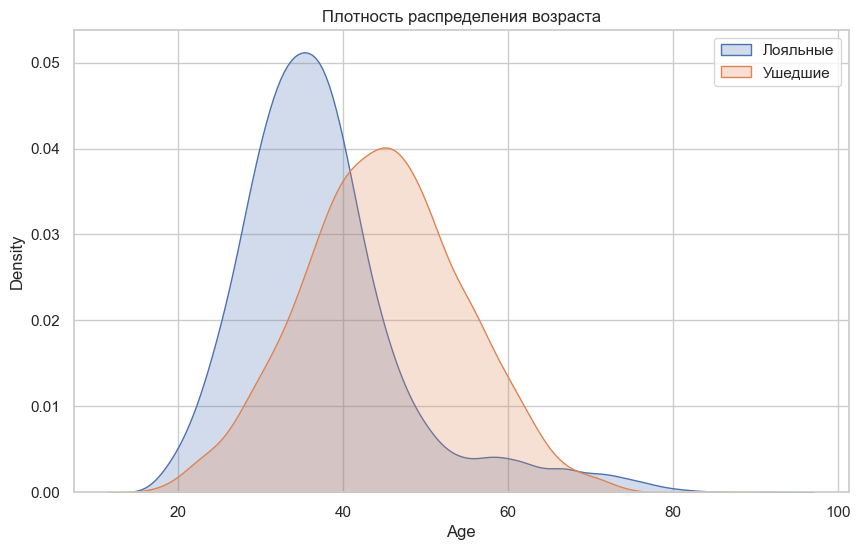

In [37]:
sns.kdeplot(df[df['Exited'] == 0]['Age'], label='Лояльные', fill=True)
sns.kdeplot(df[df['Exited'] == 1]['Age'], label='Ушедшие', fill=True)
plt.title('Плотность распределения возраста')
plt.legend()
plt.show()

### Резюме по Плотности распределения возраста:
1. Группа с выбросами: Это лояльные клиенты. Хотя их большинство, среди них пожилые люди встречаются реже, что делает их статистическими выбросами на фоне «молодого» ядра группы.
2. Банку стоит сфокусироваться на категории 40–55 лет. Так как это наиболее платежеспособная аудитория. Их уход может быть связан с тем, что банковские продукты (приложения, условия кэшбэка) ориентированы на молодежь, в то время как зрелым клиентам не хватает надежности, понятных условий по вкладам или качественного сервиса в отделениях.

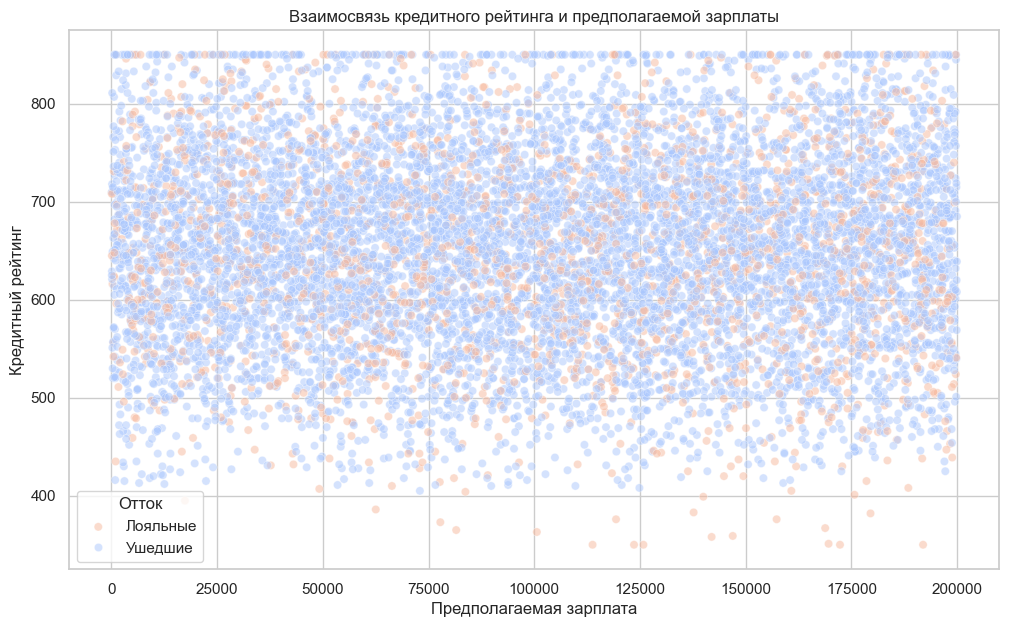

In [38]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='EstimatedSalary', 
    y='CreditScore', 
    hue='Exited', 
    alpha=0.5, 
    palette='coolwarm'
)
plt.title('Взаимосвязь кредитного рейтинга и предполагаемой зарплаты')
plt.xlabel('Предполагаемая зарплата')
plt.ylabel('Кредитный рейтинг')
plt.legend(title='Отток', labels=['Лояльные', 'Ушедшие'])
plt.show()

### Резюме по Взаимосвязи кредитного рейтинга и предполагаемой зарплатой:
1. На графике равномерно распределенное «облако» точек. Это указывает на то, что явной корреляции между кредитным рейтингом и зарплатой нет.

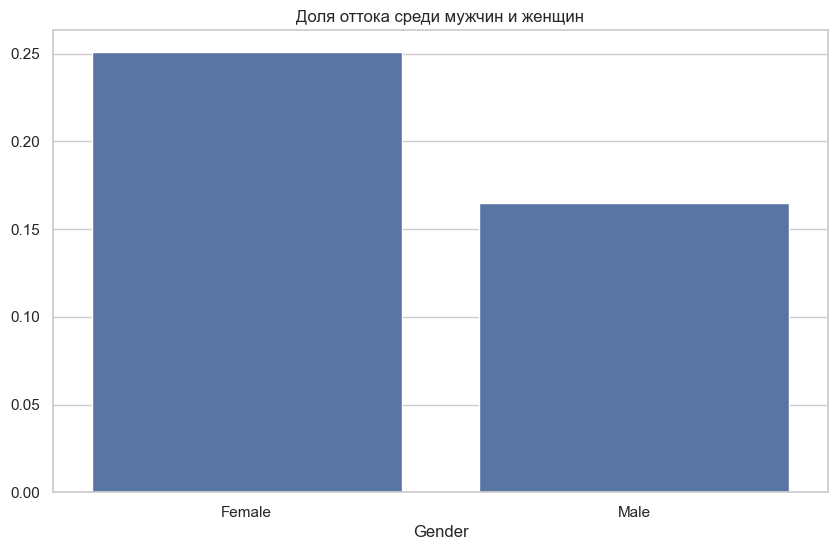

In [42]:
gender_exit = df.groupby('Gender')['Exited'].mean()
sns.barplot(x=gender_exit.index, y=gender_exit.values)
plt.title('Доля оттока среди мужчин и женщин')
plt.show()

### Резюме по Доля оттока среди мужчин и женщин:
1. Графике явно видно, что отток среди женщин выше.
2. Возможно необходимо добавить таргетинг в сторону женской части населения

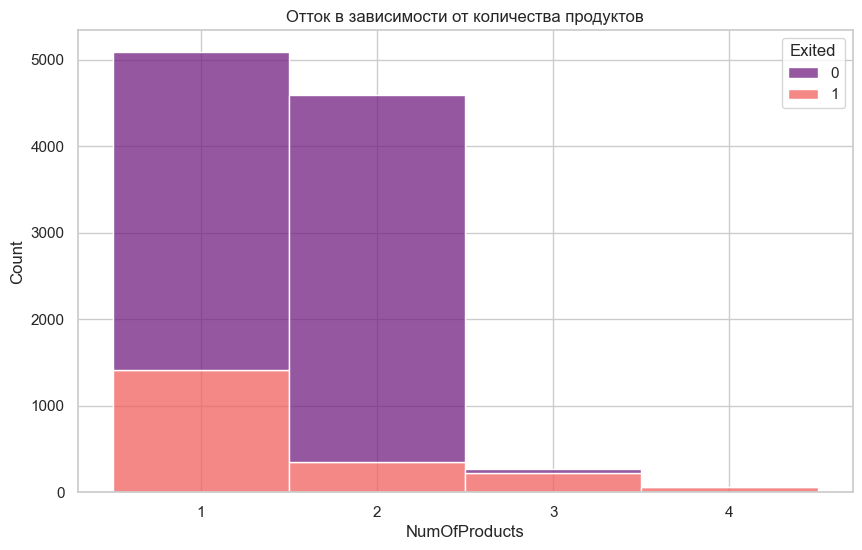

In [47]:
import matplotlib.ticker as ticker
ax = sns.histplot(data=df, x='NumOfProducts', discrete=True, hue='Exited', palette='magma', multiple='stack', legend=True)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
#plt.legend(title='Статус клиента', labels=['Остался','Ушел'])
plt.title('Отток в зависимости от количества продуктов')
plt.show()

### Резюме по Оттоку в зависимости от кол-ва продуктов:
1. По графику можно сделать вывод, что при кол-ве продуктов от 3 до 4, процент ушедших клиентов стриметится к 100%
2. Это может быть признаком «вынужденного» использования продуктов (например, когда при взятии кредита навязывают страховку и карту), что вызывает недовольство и последующий уход.

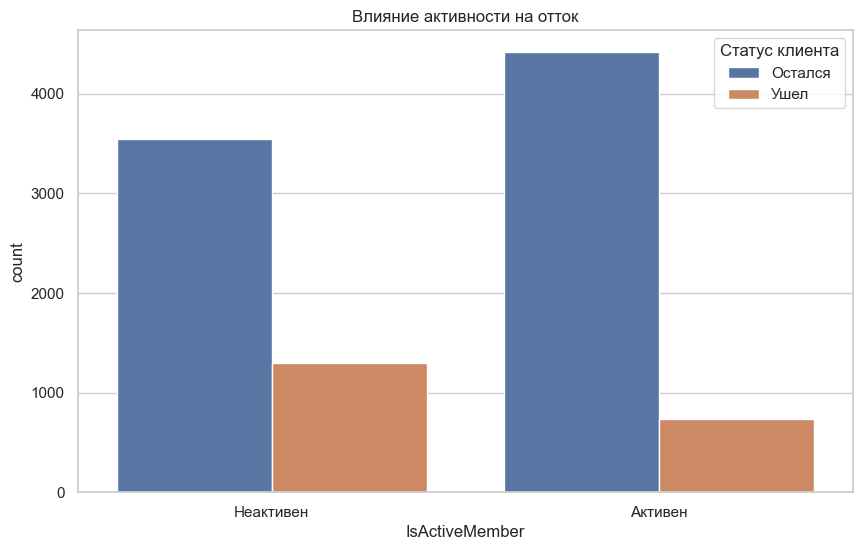

In [19]:
sns.countplot(data=df, x='IsActiveMember', hue='Exited')
plt.legend(title='Статус клиента', labels=['Остался','Ушел'])
plt.title('Влияние активности на отток')
plt.xticks([0, 1], ['Неактивен', 'Активен'])
plt.show()

### Резюме по Влияюнию активности на отток:
1. По графику можно сделать вывод, если клиент становится неактивным(перестает пользоваться продуктами банка), большая вероятность, что он уйдет.
2. В качестве рекомендаций, требуется, чтобы банк был основным у клиента, дл этого можно добавить программы лояльности, делать привлекательных кешбэк, предлагать какие-нибудь выгоды для зарплатных клиентов(чтобы ЗП клиент получал на счет в нашем банкеа) или предлагать условия автоплатежей(на связь или ЖКХ). Так же для клиентов у которых уже упала акливность, продумать персональные предложения, например по вкладу.

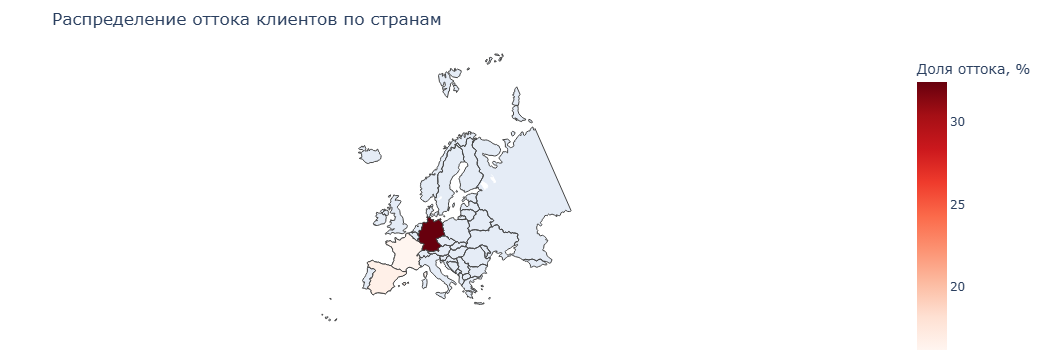

  Geography  Churn_Rate (%)
0    France           16.15
1   Germany           32.44
2     Spain           16.67


In [49]:

import plotly.express as px
churn_by_country = df.groupby('Geography')['Exited'].mean().reset_index()
churn_by_country['Churn_Rate (%)'] = (churn_by_country['Exited'] * 100).round(2)
# Добавляем ISO-коды стран для корректного отображения на карте
iso_mapping = {
    'Germany': 'DEU',
    'France': 'FRA',
    'Spain': 'ESP'
}
churn_by_country['ISO_Code'] = churn_by_country['Geography'].map(iso_mapping)
fig = px.choropleth(
    churn_by_country, 
    locations="ISO_Code", 
    color="Churn_Rate (%)",
    hover_name="Geography",
    hover_data={'ISO_Code': False, 'Exited': False, 'Churn_Rate (%)': True},
    color_continuous_scale="Reds",
    title="Распределение оттока клиентов по странам",
    labels={'Churn_Rate (%)': 'Доля оттока, %'}
)
fig.update_geos(
    scope='europe',
    showlakes=True, 
    lakecolor='rgb(255, 255, 255)'
)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()
# выведем таблицу для проверки
print(churn_by_country[['Geography', 'Churn_Rate (%)']])

### Резюме по РАспределению оттока по странам:
1.Глядя на карту и результаты анализа, мы видим аномалию: в Германии уровень оттока (~32%) почти в два раза выше, чем во Франции или Испании (~16%).
2. В немецкой выборке наблюдается корреляция: у уходящих клиентов баланс на счету выше, чем у тех, кто остается.Возможно, в Германии люди более склонны диверсифицировать накопления. Если банк предлагает низкие проценты по вкладам или вводит комиссии за обслуживание крупных счетов, «богатые» клиенты быстро переводят средства в другие финансовые институты или инвестиционные инструменты.

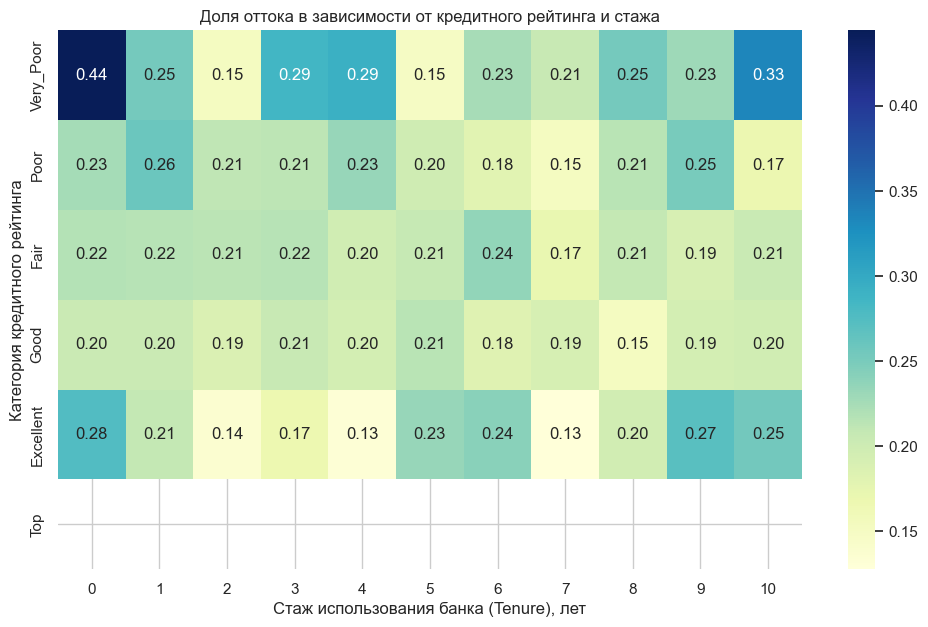

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Функция классификации
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"


df['CreditScoreCat'] = df['CreditScore'].apply(get_credit_score_cat)
pivot = df.pivot_table(
    values='Exited', 
    index='CreditScoreCat', 
    columns='Tenure', 
    aggfunc='mean'
)
reorder_list = ['Very_Poor', 'Poor', 'Fair', 'Good', 'Excellent', 'Top']
pivot = pivot.reindex(reorder_list)
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Доля оттока в зависимости от кредитного рейтинга и стажа')
plt.xlabel('Стаж использования банка (Tenure), лет')
plt.ylabel('Категория кредитного рейтинга')
plt.show()


### Резюме по Доле оттока в зависимости от кредитного рейтинга и стажа:
1.На тепловой карте мы видим, что чаще всего уходят клиенты из категории Very_Poor (очень низкий кредитный рейтинг).